In [33]:
import pandas as pd
import kagglehub
from src.dataloader import load_dataset
from house_prices.utils import extract_street_info
from src.preprocessing import target_encode, one_hot_encode, log_transform, inverse_log_transform
import re
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [34]:
# Load the dataset
path = kagglehub.dataset_download("debayank2024/house-price-prediction")
df = load_dataset(path)

Loading dataset from: /home/mordicus/.cache/kagglehub/datasets/debayank2024/house-price-prediction/versions/1/modified_data.csv


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   str    
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   str    
 15  city            4600 non-null   str    
 16  statezip        4600 non-null   str    
 17  price_per_sqft  4600 non-null   float64
dtyp

The dataset does not have missing values.

In [36]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,265.876209
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,357.503362
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,180.817500
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,243.855000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,314.840000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,22533.900000


... but no sample should have a price of 0.0.

In [37]:
# Count rows which have 'price' equal to 0
zero_price_count = (df['price'] == 0.0).sum()
print(f"Number of rows with zero price: {zero_price_count}")

Number of rows with zero price: 49


Given the 49/4600 samples with essentially missing values in 'price', just drop the missing.

In [38]:
# Remove rows where price is 0
df = df[df['price'] > 0.0]

Check the distribution of the target variable (i.e. price).

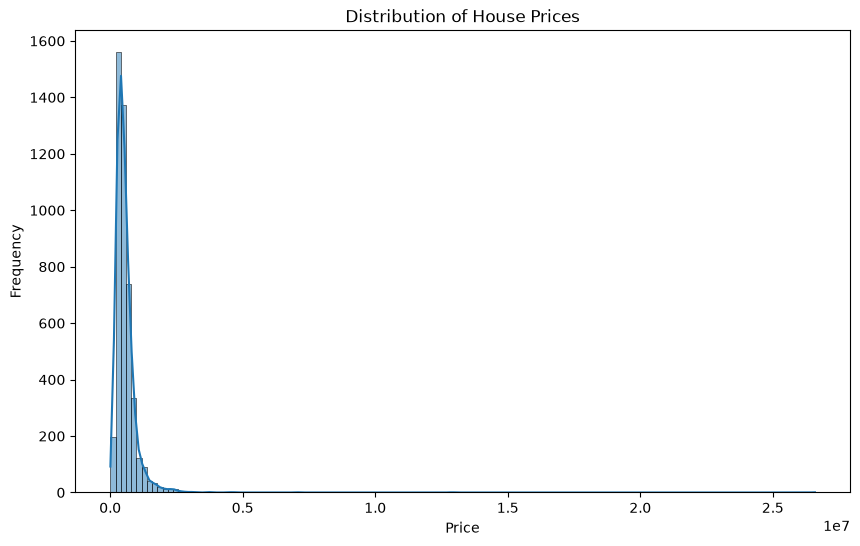

In [39]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

The target distribution is higly skewed to the right. This will likely require log-transformation, depending on the model-type.

In [40]:
# Log-transform the 'price' column to reduce skewness
df = log_transform(df, 'price')

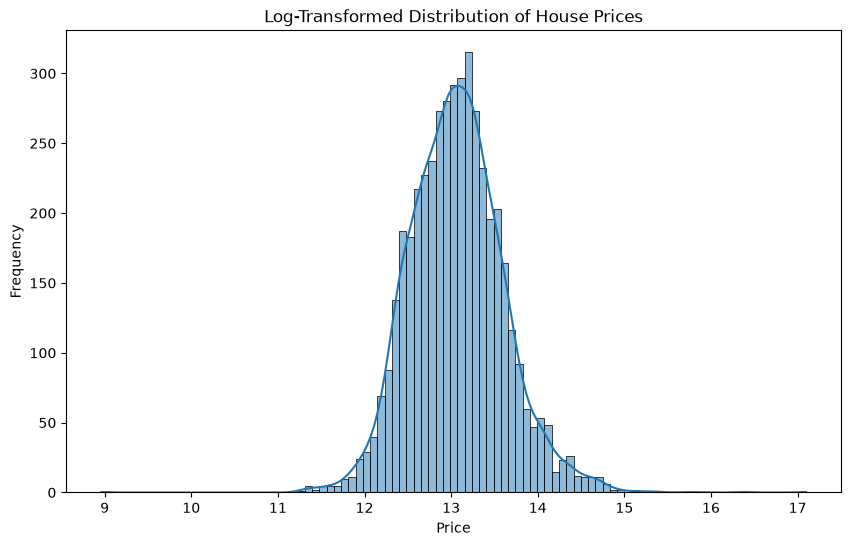

In [41]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title('Log-Transformed Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Plot prices over time. What is the timeline of samples? Is there a seasonal trend? (e.g., do prices spike in summer?). This helps decide what should be extracted. 

In [42]:
df['date'] = pd.to_datetime(df['date'])

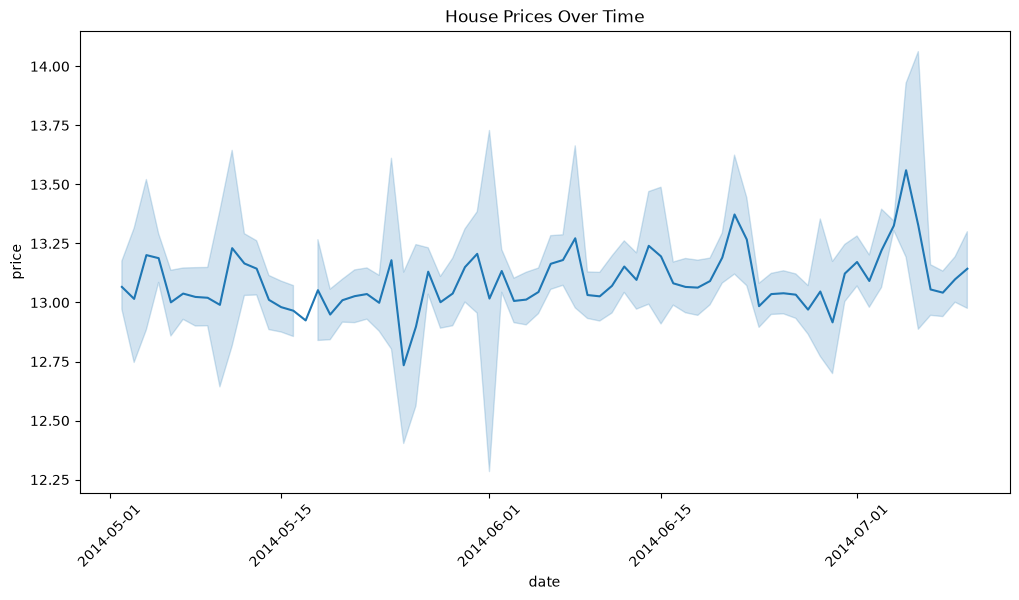

In [43]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='price')
plt.title('House Prices Over Time')
plt.xticks(rotation=45)
plt.show()

Given the short span, extract days.

<Axes: xlabel='date'>

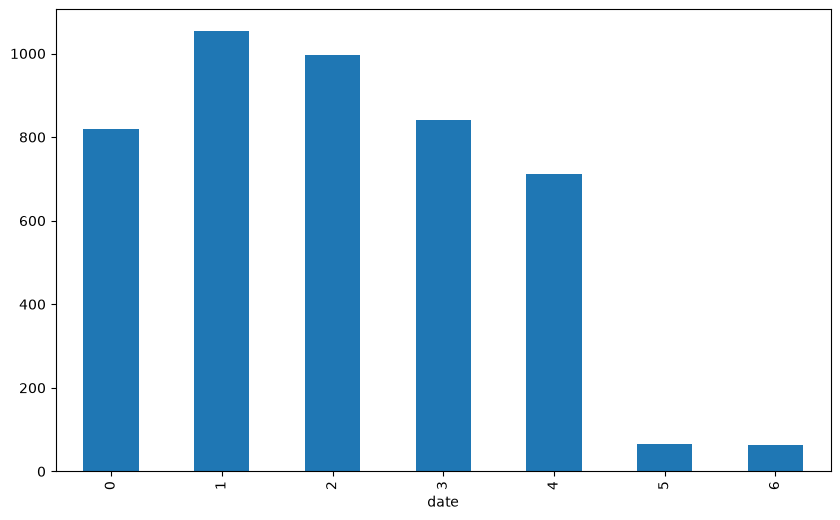

In [44]:
df['date'].dt.weekday.value_counts().sort_index().plot(kind='bar', figsize=(10, 6))

In [45]:
# Extracting the weekday from the 'date' column
df['weekday'] = df['date'].dt.weekday

In [46]:
# Extracting the number of days since the first date in the dataset
df['days_since_first'] = (df['date'] - df['date'].min()).dt.days

In [47]:
# Drop the original 'date' column if it's no longer needed
df.drop(columns=['date'], inplace=True)

__Univariate Analysis for Key Features:__

- You visualized the distribution of `price`, but you should also visualize the distributions of key numerical features (e.g., `bedrooms`, `bathrooms`, `sqft_living`). This helps identify if certain features are heavily skewed or have significant outliers that might need capping or transformation.


Proceed on geographic information in the data and prepare for encoding.

In [48]:
for col in ['street', 'city', 'statezip']:
    print(f"{col} cardinality: {df[col].nunique()}")

street cardinality: 4476
city cardinality: 44
statezip cardinality: 77


street-column has high cardinality and is useless as a feature.

In [49]:
# Define common US street suffixes
# We use \b to ensure we match whole words and [A-Za-z] to capture the letters
suffixes = [
    'Ave', 'Avenue', 'St', 'Street', 'Blvd', 'Boulevard', 
    'Dr', 'Drive', 'Ln', 'Lane', 'Ct', 'Court', 'Way', 
    'Ter', 'Terrace', 'Cir', 'Circle', 'Pl', 'Place', 
    'Rd', 'Road', 'Parkway', 'Trace', 'Trail'
]

# Create a regex pattern: \b(Ave|Avenue|St|Street|...)\b
# We sort by length descending to ensure "Avenue" is matched before "Ave"
suffixes.sort(key=len, reverse=True)
pattern = r'\b(' + '|'.join(map(re.escape, suffixes)) + r')\b'


In [50]:
# Apply the extraction
df[['street_name', 'street_type']] = df['street'].apply(
    lambda x: pd.Series(extract_street_info(pattern = pattern, street_name = x))
)

# Define the canonical mapping. This maps abbreviations to their full, standard names
suffix_mapping = {
    'Ave': 'Avenue',
    'Avenue': 'Avenue',
    'St': 'Street',
    'Street': 'Street',
    'Blvd': 'Boulevard',
    'Boulevard': 'Boulevard',
    'Dr': 'Drive',
    'Drive': 'Drive',
    'Ln': 'Lane',
    'Lane': 'Lane',
    'Ct': 'Court',
    'Court': 'Court',
    'Rd': 'Road',
    'Road': 'Road',
    'Pl': 'Place',
    'Place': 'Place',
    'Cir': 'Circle',
    'Circle': 'Circle',
    'Ter': 'Terrace',
    'Terrace': 'Terrace',
    'Way': 'Way',
    'Tr': 'Trace',
    'Trail': 'Trail'
}

#Normalize the extracted street_type
# This replaces the extracted value with the canonical name
df['street_type'] = df['street_type'].map(suffix_mapping).fillna(df['street_type'])

# Check the new distribution
print("Street Type Distribution:")
print(df['street_type'].value_counts())

# Show a few examples
print("\nSample of extracted data:")
print(df[['street', 'street_name', 'street_type']].head(10))

Street Type Distribution:
street_type
Avenue       1923
Street       1157
Place         800
Court         173
Way           154
Drive         121
Road           69
Lane           53
Other          35
Boulevard      31
Terrace        14
Trail          13
Circle          8
Name: count, dtype: int64

Sample of extracted data:
                     street           street_name street_type
0      18810 Densmore Ave N        18810 Densmore      Avenue
1           709 W Blaine St          709 W Blaine      Street
2  26206-26214 143rd Ave SE     26206-26214 143rd      Avenue
3           857 170th Pl NE             857 170th       Place
4         9105 170th Ave NE            9105 170th      Avenue
5            522 NE 88th St           522 NE 88th      Street
6         2616 174th Ave NE            2616 174th      Avenue
7         23762 SE 253rd Pl        23762 SE 253rd       Place
8   46611-46625 SE 129th St  46611-46625 SE 129th      Street
9          6811 55th Ave NE             6811 55th      

In [51]:
# Drop the original 'street' and 'street_name' columns
df.drop(columns=['street', 'street_name'], inplace=True)

Check the counts for `street_type` to confirm if any category is so rare that it should be grouped into an "Other" category before encoding to avoid overfitting.


<Axes: title={'center': 'Street Type Distribution'}, xlabel='street_type'>

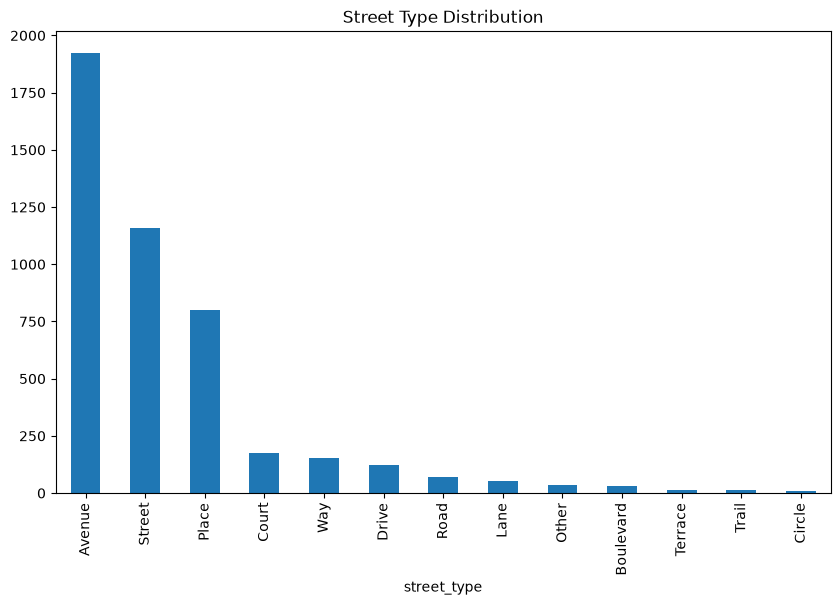

In [52]:
df['street_type'].value_counts().plot(kind='bar', figsize=(10, 6), title='Street Type Distribution')

In [53]:
# Define a threshold (e.g., categories appearing in less than 2% of the data)
threshold = 0.02 * len(df)
counts = df['street_type'].value_counts()
rare_types = counts[counts < threshold].index

# Replace rare types with 'Other'
df['street_type'] = df['street_type'].apply(lambda x: 'Other' if x in rare_types else x)

In [54]:
df['street_type'].value_counts()

street_type
Avenue    1923
Street    1157
Place      800
Other      223
Court      173
Way        154
Drive      121
Name: count, dtype: int64

state, city and zip provide useful geographic information but need to be encoded.

In [55]:
# Split statezip into state and zip columns
df[['state', 'zip']] = df['statezip'].str.split(' ', expand=True)
# Drop the original 'statezip' column
df.drop(columns=['statezip'], inplace=True)

Count unique values in state, city and zip for the purposes of encoding.

In [56]:
df['state'].unique().value_counts().sum()

np.int64(1)

state is clearly useless.

In [57]:
# Drop the 'state' column
df.drop(columns=['state'], inplace=True)

In [58]:
df['city'].unique().value_counts().sum()

np.int64(44)

In [59]:
df['zip'].unique().value_counts().sum()

np.int64(77)

Identify "hot" geographic areas or neighborhoods that drive up prices. 

In [60]:
# Check if zip codes are unique to cities
is_zip_unique = df.groupby('zip')['city'].nunique().max() == 1
print(f"Is zip unique to city? {is_zip_unique}")


Is zip unique to city? False


In [61]:
df.groupby(['city', 'zip'])['price'].mean().sort_values(ascending=False).describe()#.head(10)

count    103.000000
mean      12.977878
std        0.464485
min       12.188837
25%       12.591452
50%       12.959847
75%       13.297960
max       14.350543
Name: price, dtype: float64

The above suggest that target encoding is the best choice, given that there is (just) over 100 categories. It just encodes each category with its expected value (i.e. mean).

In [62]:
# Create a new column that combines city and zip for better granularity
df['cityzip'] = df['city'] + "_" + df['zip']
# Drop the original city and zip columns if desired
df.drop(columns=['city', 'zip'], inplace=True)


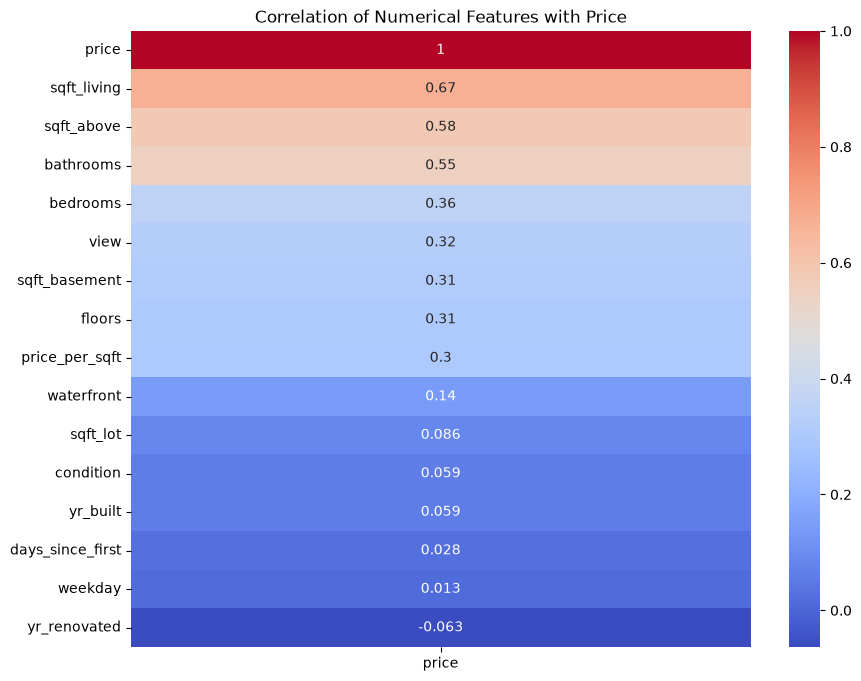

Top correlations with price:
price               1.000000
sqft_living         0.671307
sqft_above          0.582012
bathrooms           0.548583
bedrooms            0.355346
view                0.324040
sqft_basement       0.312636
floors              0.305319
price_per_sqft      0.298868
waterfront          0.141863
sqft_lot            0.085856
condition           0.059256
yr_built            0.059101
days_since_first    0.028089
weekday             0.013266
yr_renovated       -0.063173
Name: price, dtype: float64


In [63]:
# Correlation Analysis
# Select numerical columns for correlation
numerical_df = df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()

# Visualize the correlation with 'price'
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix['price'].sort_values(ascending=False).to_frame(), annot=True, cmap='coolwarm')
plt.title('Correlation of Numerical Features with Price')
plt.show()

# Print top correlations
print("Top correlations with price:")
print(correlation_matrix['price'].sort_values(ascending=False))

__Bivariate Relationship Plots:__

- While you have a correlation heatmap, adding __Scatter Plots__ for the top 3-5 most correlated features against `price` (e.g., `sqft_living` vs `price`, `bathrooms` vs `price`) helps identify non-linear relationships that a heatmap might miss.


Multicollinearity analysis is needed.

In [64]:
# Calculate Variance Inflation Factor (VIF) for all features of df
# price is the target
numerical_df = df.drop(columns=['price']).select_dtypes(include=['number'])
vif_data = []
for i, col in enumerate(numerical_df.columns):
    vif = variance_inflation_factor(numerical_df.values, i)
    vif_data.append({'feature': col, 'VIF': vif})

vif_df = pd.DataFrame(vif_data)
vif_df.sort_values(by='VIF', ascending=False)

/tmp/ipykernel_2220778/3566745012.py:6: UserWarning: The design matrix is poorly conditioned (condition number=2.82e+15). VIF calculations may be numerically unstable.
  vif = variance_inflation_factor(numerical_df.values, i)
/home/mordicus/Documents/Projektit/Data Science/Kaggle/House prices/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/home/mordicus/Documents/Projektit/Data Science/Kaggle/House prices/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/home/mordicus/Documents/Projektit/Data Science/Kaggle/House prices/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The d

,feature,VIF
2,sqft_living,1.000800e+15
9,sqft_basement,1.000800e+15
8,sqft_above,1.000800e+15
1,bathrooms,3.270206e+00
10,yr_built,1.910018e+00
4,floors,1.878152e+00
0,bedrooms,1.687890e+00
7,condition,1.435319e+00
6,view,1.330532e+00
11,yr_renovated,1.319750e+00


sqft_living is just a linear combination of sqft_above and sqft_basement.

In [65]:
(df['sqft_above'] + df['sqft_basement'] == df['sqft_living']).unique()

array([ True])

In [66]:
df.drop(columns=['sqft_living'], inplace=True)

In [67]:
# Drop price_per_sqft as it is a derived feature
df.drop(columns=['price_per_sqft'], inplace=True)

__Summary of Insights:__

- The notebook ends with code. A final Markdown cell summarizing the __key takeaways__ (e.g., "Price is highly dependent on X," "We found a seasonal spike in Y," "We decided to drop Z because...") is essential for transitioning into the modeling phase.
